# 05 - Model Evaluation

## CRISP-DM Evaluation Stage

This notebook consolidates completed model evaluation for SentiRank. It reads existing experiment outputs only; it does not train IndoBERT, train SVM, fit TF-IDF, scrape data, or calculate AHP/Fuzzy AHP weights.

## Research Context

SentiRank uses IndoBERT for sentiment classification, SVM for aspect classification, and AHP/Fuzzy AHP later for priority ranking comparison. The completed model decisions are:

- Final IndoBERT candidate: `run_3_weighted_loss_lr_1e-5`
- Run 4 slang normalization was evaluated but did not outperform Run 3
- Final SVM aspect classifier candidate: `merged_5class`
- `original_7class` remains an exploratory SVM baseline

## Evaluation Objective

The objective is to summarize completed model experiments, compare selected candidates, document limitations, and prepare the handoff to Phase 10A AHP/Fuzzy AHP criteria and expert judgement design.

In [9]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display, Markdown


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "ml-service").exists()
            and (candidate / "datasets").exists()
            and (candidate / "docs").exists()
        ):
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root()

DATASET_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "05_evaluation"
FIGURE_DIR = PROJECT_ROOT / "docs" / "figures" / "05_evaluation"
INDOBERT_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "03_indobert"
SVM_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "04_svm"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_OUTPUT_DIR:", DATASET_OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


def load_json(path: Path):
    if not path.exists():
        print(f"Missing JSON: {path.relative_to(PROJECT_ROOT)}")
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_csv(path: Path):
    if not path.exists():
        print(f"Missing CSV: {path.relative_to(PROJECT_ROOT)}")
        return pd.DataFrame()
    return pd.read_csv(path)


def show_image(path: Path, width: int = 900):
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"Missing figure: {path.relative_to(PROJECT_ROOT)}")

PROJECT_ROOT: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank
DATASET_OUTPUT_DIR: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\05_evaluation
FIGURE_DIR: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\docs\figures\05_evaluation


## Consolidated Summary

The consolidated files are generated under `datasets/outputs/eda/05_evaluation/` and figures under `docs/figures/05_evaluation/`.

In [10]:
summary = load_json(DATASET_OUTPUT_DIR / "model_evaluation_summary.json")
summary_table = load_csv(DATASET_OUTPUT_DIR / "model_evaluation_summary.csv")

if summary:
    display(Markdown(f"**Selected IndoBERT model:** `{summary['selected_indobert_model']}`"))
    display(Markdown(f"**Selected SVM model:** `{summary['selected_svm_model']}`"))

summary_table

**Selected IndoBERT model:** `run_3_weighted_loss_lr_1e-5`

**Selected SVM model:** `merged_5class`

,model_component,candidate_name,task,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,status,note
0,IndoBERT,run_1_baseline,Sentiment classification,0.741614,0.702738,0.687521,0.692673,0.734539,0.741614,0.736450,baseline,Baseline fine-tuning; highest accuracy but wea...
1,IndoBERT,run_2_weighted_loss,Sentiment classification,0.732820,0.703145,0.715073,0.703375,0.756353,0.732820,0.740310,experiment,Weighted loss improved Neutral recall and Macr...
2,IndoBERT,run_3_weighted_loss_lr_1e-5,Sentiment classification,0.736229,0.708568,0.723401,0.709326,0.761870,0.736229,0.744468,selected,"Selected final candidate; best Macro F1, Weigh..."
3,IndoBERT,run_4_weighted_loss_lr_1e-5_slang_norm,Sentiment classification,0.732138,0.692261,0.698439,0.693988,0.741980,0.732138,0.736053,experiment,Slang normalization experiment; did not outper...
4,SVM,original_7class,Aspect classification,0.945228,0.940556,0.867642,0.891968,0.945207,0.945228,0.944945,baseline,Exploratory 7-class baseline with higher minor...
5,SVM,merged_5class,Aspect classification,0.950207,0.934127,0.940288,0.936781,0.950260,0.950207,0.950142,selected,Selected stable taxonomy aligned with AHP/Fuzz...


## IndoBERT Sentiment Model Evaluation Summary

Run 3 is selected because it has the strongest completed balance: highest Macro F1, highest Weighted F1, best Neutral F1, and a better Neutral recall trade-off than Run 2. Run 4 did not improve the overall result after slang normalization.

In [11]:
if not summary_table.empty:
    indobert_table = summary_table[summary_table["model_component"] == "IndoBERT"].copy()
    display(indobert_table)

if summary:
    indobert_detail = pd.DataFrame(summary.get("indobert_run_comparison", []))
    display(indobert_detail[[
        "candidate_name", "status", "accuracy", "test_loss", "precision_macro", "recall_macro", "f1_macro",
        "f1_weighted", "neutral_precision", "neutral_recall", "neutral_f1"
    ]])

,model_component,candidate_name,task,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,status,note
0,IndoBERT,run_1_baseline,Sentiment classification,0.741614,0.702738,0.687521,0.692673,0.734539,0.741614,0.736450,baseline,Baseline fine-tuning; highest accuracy but wea...
1,IndoBERT,run_2_weighted_loss,Sentiment classification,0.732820,0.703145,0.715073,0.703375,0.756353,0.732820,0.740310,experiment,Weighted loss improved Neutral recall and Macr...
2,IndoBERT,run_3_weighted_loss_lr_1e-5,Sentiment classification,0.736229,0.708568,0.723401,0.709326,0.761870,0.736229,0.744468,selected,"Selected final candidate; best Macro F1, Weigh..."
3,IndoBERT,run_4_weighted_loss_lr_1e-5_slang_norm,Sentiment classification,0.732138,0.692261,0.698439,0.693988,0.741980,0.732138,0.736053,experiment,Slang normalization experiment; did not outper...


,candidate_name,status,accuracy,test_loss,precision_macro,recall_macro,f1_macro,f1_weighted,neutral_precision,neutral_recall,neutral_f1
0,run_1_baseline,baseline,0.741614,0.600660,0.702738,0.687521,0.692673,0.736450,0.563825,0.452552,0.502097
1,run_2_weighted_loss,experiment,0.732820,0.680158,0.703145,0.715073,0.703375,0.740310,0.472370,0.636673,0.542351
2,run_3_weighted_loss_lr_1e-5,selected,0.736229,0.665705,0.708568,0.723401,0.709326,0.744468,0.477015,0.666919,0.556204
3,run_4_weighted_loss_lr_1e-5_slang_norm,experiment,0.732138,0.731941,0.692261,0.698439,0.693988,0.736053,0.475277,0.552363,0.510928


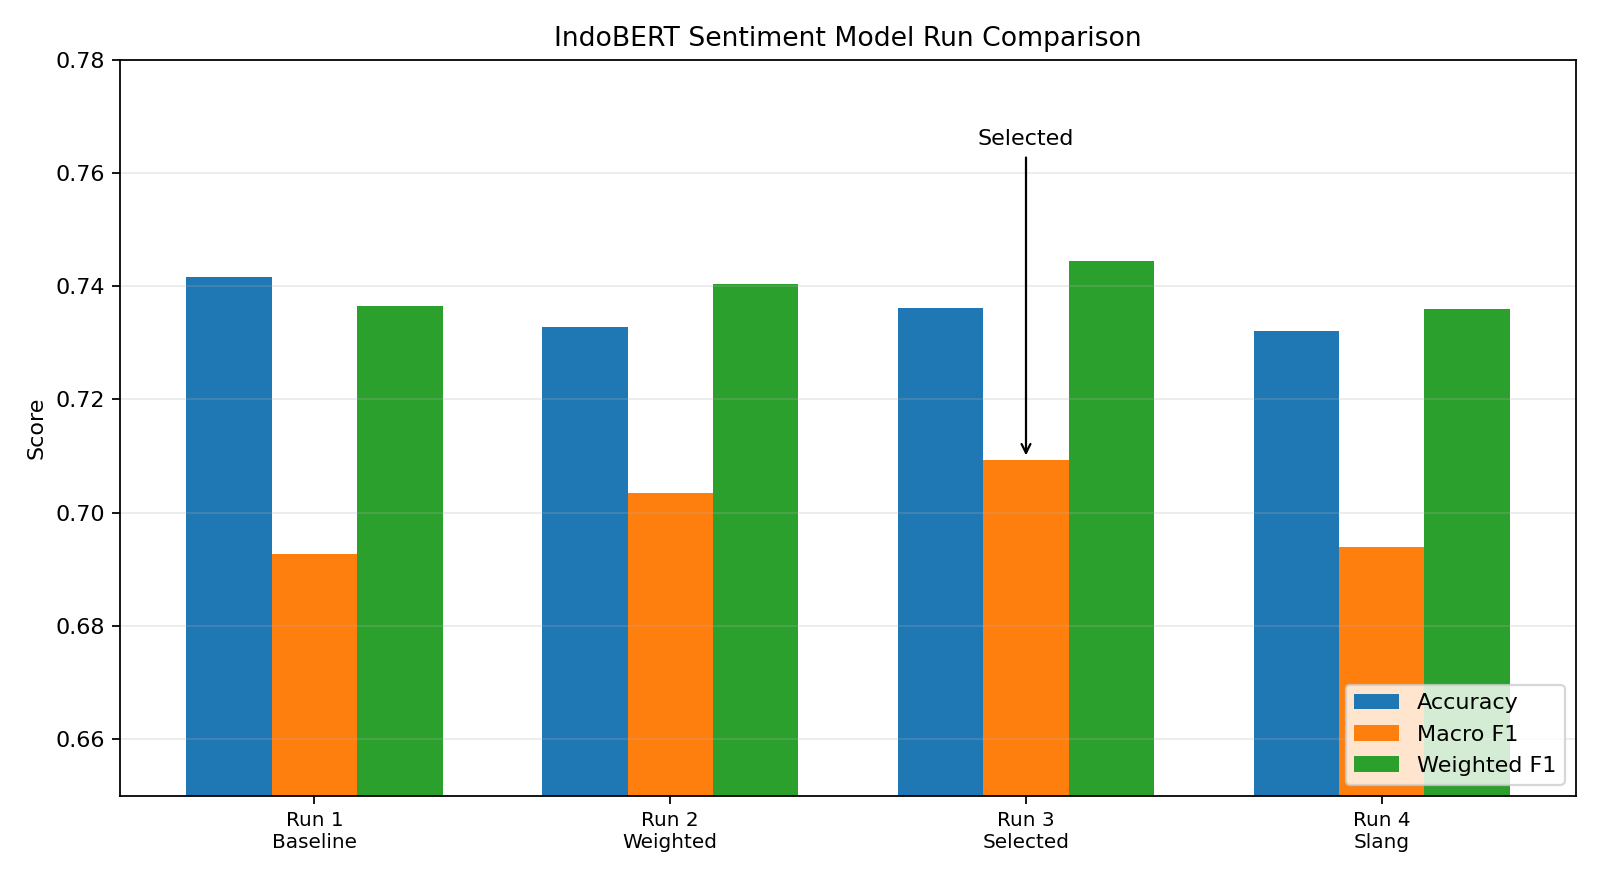

In [12]:
show_image(FIGURE_DIR / "indobert_run_comparison.png")

## SVM Aspect Classifier Evaluation Summary

The selected SVM scenario is `merged_5class`. It improves Macro F1 and minimum class F1 while producing a more stable and interpretable taxonomy for AHP/Fuzzy AHP expert comparison.

In [13]:
if not summary_table.empty:
    svm_table = summary_table[summary_table["model_component"] == "SVM"].copy()
    display(svm_table)

if summary:
    svm_detail = pd.DataFrame(summary.get("svm_scenario_comparison", []))
    display(svm_detail[[
        "candidate_name", "status", "accuracy", "precision_macro", "recall_macro", "f1_macro",
        "f1_weighted", "min_class_f1"
    ]])

,model_component,candidate_name,task,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,status,note
4,SVM,original_7class,Aspect classification,0.945228,0.940556,0.867642,0.891968,0.945207,0.945228,0.944945,baseline,Exploratory 7-class baseline with higher minor...
5,SVM,merged_5class,Aspect classification,0.950207,0.934127,0.940288,0.936781,0.950260,0.950207,0.950142,selected,Selected stable taxonomy aligned with AHP/Fuzz...


,candidate_name,status,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,min_class_f1
0,original_7class,baseline,0.945228,0.940556,0.867642,0.891968,0.944945,0.666667
1,merged_5class,selected,0.950207,0.934127,0.940288,0.936781,0.950142,0.889831


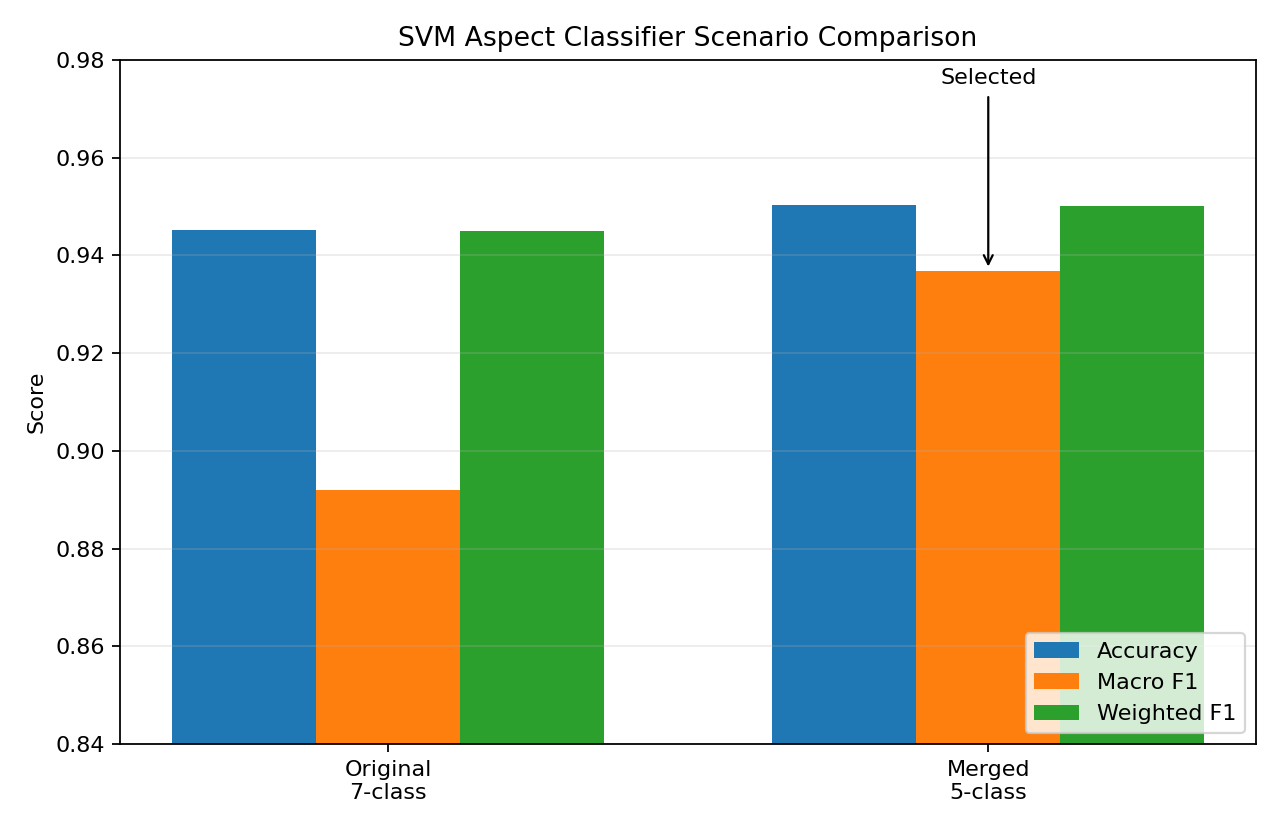

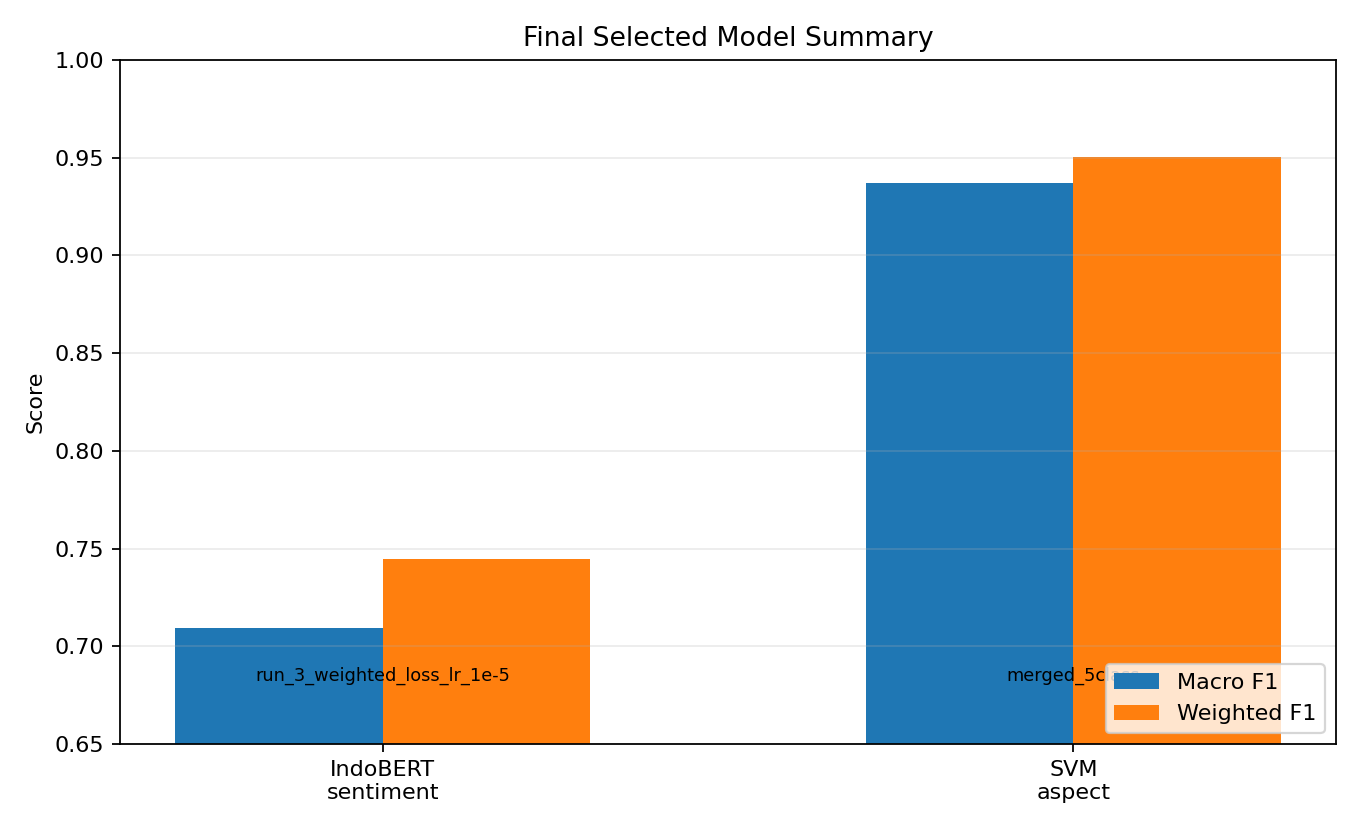

In [14]:
show_image(FIGURE_DIR / "svm_scenario_comparison.png")
show_image(FIGURE_DIR / "final_model_selection_summary.png")

## Classification Reports And Confusion Matrices

The cells below read detailed reports and confusion matrices if the Phase 8 and Phase 9 output files are available locally.

In [15]:
selected_indobert_report = load_json(INDOBERT_OUTPUT_DIR / "run_3_weighted_loss_lr_1e-5" / "indobert_classification_report.json")
if selected_indobert_report:
    display(pd.DataFrame(selected_indobert_report).T)

selected_svm_report = load_json(SVM_OUTPUT_DIR / "svm_merged_5class_classification_report.json")
if selected_svm_report:
    display(pd.DataFrame(selected_svm_report).T)

svm_confusion = load_csv(SVM_OUTPUT_DIR / "svm_merged_5class_confusion_matrix.csv")
if not svm_confusion.empty:
    display(svm_confusion)

,f1-score,precision,recall,support
Negative,0.786187,0.804501,0.768688,5953.000000
Neutral,0.556204,0.477015,0.666919,2645.000000
Positive,0.785588,0.844188,0.734596,6070.000000
accuracy,0.736229,0.736229,0.736229,0.736229
macro avg,0.709326,0.708568,0.723401,14668.000000
weighted avg,0.744468,0.761870,0.736229,14668.000000


,f1-score,precision,recall,support
Account/Login,0.949495,0.912621,0.989474,95.000000
Ads Experience,0.946910,0.946087,0.947735,574.000000
App Reliability & Usability,0.889831,0.913043,0.867769,121.000000
"Features, Content & Audio Experience",0.963553,0.964765,0.962343,1195.000000
Subscription & Pricing,0.934118,0.934118,0.934118,425.000000
accuracy,0.950207,0.950207,0.950207,0.950207
macro avg,0.936781,0.934127,0.940288,2410.000000
weighted avg,0.950142,0.950260,0.950207,2410.000000


,true_label,Account/Login,Ads Experience,App Reliability & Usability,"Features, Content & Audio Experience",Subscription & Pricing
0,Account/Login,94,0,0,0,1
1,Ads Experience,1,544,2,18,9
2,App Reliability & Usability,2,3,105,7,4
3,"Features, Content & Audio Experience",3,21,7,1150,14
4,Subscription & Pricing,3,7,1,17,397


## Final Model Selection

- Sentiment classification: `run_3_weighted_loss_lr_1e-5`
- Aspect classification: `merged_5class`

These selected models support the ranking pipeline but do not replace expert judgement for AHP/Fuzzy AHP weights.

## Relationship To AHP/Fuzzy AHP

The SVM `merged_5class` scenario defines candidate criteria that are more stable than the original 7-class weak-label taxonomy. These criteria should be used as the starting point for expert judgement design, not as final weighted criteria.

In [16]:
taxonomy = load_json(SVM_OUTPUT_DIR / "final_aspect_taxonomy_for_ahp.json")
if taxonomy:
    criteria = pd.DataFrame(taxonomy.get("criteria", []))
    display(criteria)

,description,name,note,source_labels,use_in_ahp
0,"Issues related to available features, playlist...","Features, Content & Audio Experience",Candidate AHP/Fuzzy AHP criterion; requires ex...,"[Features & Content, Audio Quality]",True
1,"Issues related to performance, stability, erro...",App Reliability & Usability,Candidate AHP/Fuzzy AHP criterion; requires ex...,"[Performance & Stability, UI/UX]",True
2,"Issues related to advertisement frequency, int...",Ads Experience,Candidate AHP/Fuzzy AHP criterion; requires ex...,[Ads Experience],True
3,"Issues related to premium subscription, price,...",Subscription & Pricing,Candidate AHP/Fuzzy AHP criterion; requires ex...,[Subscription & Pricing],True
4,"Issues related to account access, login failur...",Account/Login,Candidate AHP/Fuzzy AHP criterion; requires ex...,[Account/Login],True


## Model Limitations

- IndoBERT performance still depends on the quality of the prepared sentiment labels.
- SVM was trained and evaluated using weak aspect labels, so results measure how well the model learns keyword-derived aspect patterns rather than expert-validated ground truth.
- AHP/Fuzzy AHP has not been calculated in this notebook; expert judgement validation is required before final priority ranking.

## Next Step

Proceed to **Phase 10A AHP/Fuzzy AHP Criteria and Expert Judgement Design**.